# Physical-event learning curves

Wave dynamics on a ring. Curves are mean ± standard error across JSONL seed runs.

In [15]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

font_manager.fontManager = font_manager._load_fontmanager(try_read_cache=False)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
PAPER_FONT = next((name for name in ('Source Sans 3', 'Source Sans Pro', 'Nimbus Sans', 'Ubuntu Sans', 'Liberation Sans', 'DejaVu Sans') if name in available_fonts), 'DejaVu Sans')
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': [PAPER_FONT], 'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 6.0, 'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 600})
print(f'Publication font: {PAPER_FONT}')

RESULTS_DIR = Path('..') / 'derived' / 'results' / 'learning_curves'
# Select one coherent experimental configuration. The current clean panel is
# tau=.03 with one-step rollout evaluation; do not mix prior horizon-20/tau=0 runs.
EXPERIMENT_GLOB = '*tau0p03*rollhorizon1*.jsonl'
EXPORT = Path('..') / 'derived' / 'figures' / 'wave_ring_learning_curves.pdf'
# Shared visual identity used by rollout notebooks.
MODEL_STYLE = {
    'fnn': {'label': 'FNN', 'color': '#1f77b4', 'marker': 'o'},
    'sum/tgn_gru': {'label': 'TGN-GRU', 'color': '#ff7f0e', 'marker': 's'},
    'deepsets/tgn_gru': {'label': 'DeepSets', 'color': '#2ca02c', 'marker': '^'},
    'settransformer/tgn_gru': {'label': 'Set Transformer', 'color': '#d62728', 'marker': 'D'},
    'hopfield/hopfield_update': {'label': 'Hopfield', 'color': '#9467bd', 'marker': 'P'},
    'settransformer/lnn': {'label': 'LNN', 'color': '#8c564b', 'marker': 'X'},
    'settransformer/hnn': {'label': 'HNN', 'color': '#e377c2', 'marker': 'v'},
}


Publication font: Source Sans Pro


In [16]:
paths = sorted(RESULTS_DIR.rglob(EXPERIMENT_GLOB))
if not paths:
    raise FileNotFoundError(f'No learning-curve JSONLs found in {RESULTS_DIR}')

DISPLAY_RUNS = ('fnn',)
records = defaultdict(list)
for path in paths:
    with path.open() as handle:
        for line in handle:
            row = json.loads(line)
            if row['run'] in DISPLAY_RUNS:
                records[row['run']].append(row)
print(f'Loaded {sum(map(len, records.values()))} epoch records from {len(paths)} seed files: {sorted(records)}')

def metric(row, key):
    value = row
    for part in key.split('.'):
        value = value.get(part, np.nan) if isinstance(value, dict) else np.nan
    return float(value) if value is not None else np.nan

def aggregate(key):
    curves = {}
    for run, rows in records.items():
        by_epoch = defaultdict(list)
        for row in rows:
            value = metric(row, key)
            if np.isfinite(value): by_epoch[int(row['epoch'])].append(value)
        epochs = np.array(sorted(by_epoch))
        mean = np.array([np.mean(by_epoch[e]) for e in epochs])
        sem = np.array([np.std(by_epoch[e], ddof=1) / np.sqrt(len(by_epoch[e])) if len(by_epoch[e]) > 1 else 0 for e in epochs])
        curves[run] = (epochs, mean, sem)
    return curves


Loaded 100 epoch records from 5 seed files: ['fnn']


In [17]:
PANELS = [
    {
        'title': 'Training objective',
        'metrics': [
            ('train_step.loss', 'Train', '-'),
        ],
        'log': True,
    },
    {
        'title': 'Force recovery',
        'metrics': [
            ('val.force_mse', 'Validation', '-'),
            ('test.force_mse', 'Test', '--'),
            ('val.active_force_mse', 'Validation active', ':'),
            ('test.active_force_mse', 'Test active', '-.'),
        ],
        'log': True,
    },
    {
        'title': 'Event prediction',
        'metrics': [
            ('val.event_auprc', 'Validation', '-'),
            ('test.event_auprc', 'Test', '--'),
        ],
        'log': False,
    },
]
Y_LABELS = {
    'Training objective': 'Objective',
    'Force recovery': 'Force MSE',
    'Event prediction': 'Event AUPR',
}

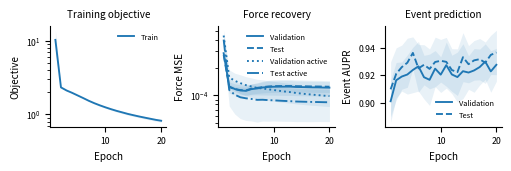

In [18]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(5.0, 1.6),
    constrained_layout=True,
)
for axis, panel in zip(axes, PANELS):
    for key, metric_label, linestyle in panel['metrics']:
        for run, (epochs, mean, sem) in aggregate(key).items():
            style = MODEL_STYLE.get(
                run,
                {'label': run, 'color': '0.3', 'marker': 'o'}
            )

            axis.plot(
                epochs,
                mean,
                label=metric_label,
                color=style['color'],
                linestyle=linestyle,
                linewidth=1.35,
            )

            axis.fill_between(
                epochs,
                mean - sem,
                mean + sem,
                color=style['color'],
                alpha=.10,
                linewidth=0,
            )

    axis.set_title(panel['title'])
    axis.set_xlabel('Epoch')
    axis.set_ylabel(Y_LABELS[panel['title']])
    axis.spines[['top', 'right']].set_visible(False)

    if panel['log']:
        axis.set_yscale('log')

    axis.legend(frameon=False)


In [19]:
EXPORT = Path('..') / 'derived' / 'results' / 'figures' / 'wave_ring_learning_curves.pdf'
EXPORT.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(
    EXPORT,
    format='pdf',
    bbox_inches='tight',
    pad_inches=0.02,
)